In [1]:
import numpy as np
import math
import cmath
import json

from numpy.linalg import eig
from numpy.linalg import det, norm

from scipy.stats import unitary_group

from scipy.special import factorial
from scipy.sparse import kron, csr_matrix
from scipy.optimize import curve_fit

pi = np.pi

import matplotlib.pyplot as plt #for plotting graph
from IPython.display import display, Math

In [2]:
import qiskit
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile

from qiskit.transpiler import CouplingMap
from qiskit.circuit.library import RealAmplitudes

from qiskit.visualization import circuit_drawer
from qiskit.visualization import plot_histogram

from qiskit import qpy
from qiskit import qasm2

from qiskit.circuit.library import CPhaseGate, XGate, XXPlusYYGate
from qiskit.circuit.library import QFT

from qiskit_ibm_runtime import Sampler, Batch, Options
from qiskit_ibm_runtime import QiskitRuntimeService

from qiskit.transpiler import generate_preset_pass_manager

from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_aer import AerSimulator
from qiskit_aer.primitives import SamplerV2 as Sampler_aer
from qiskit_aer.primitives import EstimatorV2 as Estimator_aer

simulator_Aer = AerSimulator()

The phase angle of $R_{m}$ with angle $\theta_{m}=2\pi/2^{m}$

In [3]:
def theta_m(m):
    return 2*pi/2**m

The binary representation of an integer with LSB first

In [4]:
def bits_lsb_first(a, d):
    # returns [a0, a1, ..., a_{n-1}]
    return [(a >> j) & 1 for j in range(d)]

The Qiskit function of the quantum calculator **QCalc** acting on x and y integers with control on z:
$$
\text{QCalc} |z\rangle_{1}|y\rangle_{d}|x\rangle_{d}|0\rangle_{d} = 
\begin{cases} 
|z\rangle_{1}|y\rangle_{d}|x\rangle_{d}|x+y \pmod{2^{d}}\rangle_{d}, & \text{if } z = 0 \\ 
|z\rangle_{1}|y\rangle_{d}|x\rangle_{d}|x \cdot y \pmod{2^{d}}\rangle_{d}, & \text{if } z = 1 
\end{cases}
$$

In [5]:
def QCalc(d, x, y, z):
    """ 
    The quantum circuit has 3d+1 qubits and 2 ancilla qubits. Therefore the total qubits N = 3d+3.
    Two integers x and y are chosen from the range {0, 1, 2, ..., 2^d-1}.
    |z> |x> |y> |0> -> |z> |x> |y> |x+y mod 2^d> if z = 0
    |z> |x> |y> |0> -> |z> |x> |y> |x.y mod 2^d> if z = 1
    |z> is a single qubit, |x>, |y> and |0> has d qubits.
    qr is the quantum register
    |z> is at qr[0]
    |y> register has qr[1] to qr[d]
    |a1> ancilla is at qr[d+1]
    |x> register has qr[d+2] to qr[2d+1]
    |a2> ancilla is at qr[2d+2]
    |0>  register has qr[2d+3] to qr[3d+2]
    """
    N = 3*d+1+2 # Total number of qubits
    
    # binary representation of x and y integers:
    qubit_input = [z, bits_lsb_first(y, d), bits_lsb_first(x, d)]

    qc_0 = QuantumCircuit(N)
    
# Preparing the input states
    qc_in = qc_0.copy()
    if qubit_input[0] == 1:
        qc_in.x(0)
    for i, el in enumerate(qubit_input[1]):
        if el == 1:
            qc_in.x(i+1)
    for j, ek in enumerate(qubit_input[2]):
        if ek == 1:
            qc_in.x(d+2+j)
    
    qc = qc_in.copy()
    qc.x(0)
    # QFT at |0> register: |0> -> |phi(0)>
    for p in range(d):
        qc.h(2*d+3+p)
    for s in range(d//2):
        qc.swap(2*d+3+s, 3*d+2-s)
    # Addition part starts
    # |z> |y> |x> |phi(0)> -> |z> |y> |x> |phi(x)>
    for j in range(d):
        qc.ccx(0, d+2+j, 2*d+2)
        for k in range(d-j):
            m = d-(j+k)
            if m >= 1:
                qc.cp(theta_m(m), 2*d+2, 2*d+3+k)
        qc.ccx(0, d+2+j, 2*d+2)
    # |z> |y> |x> |phi(x)> -> |z> |y> |x> |phi(x+y mod 2^d)>
    for i in range(d):
        qc.ccx(0, 1+i, 2*d+2)
        for k in range(d-i):
            m = d-(i+k)
            if m >= 1:
                qc.cp(theta_m(m), 2*d+2, 2*d+3+k)
        qc.ccx(0, 1+i, 2*d+2)
    # Addition part ends
    qc.x(0)
    #qc.barrier()

    # Multiplication part starts
    for i in range(d):
        qc.ccx(0, i+1, d+1)
        for j in range(d-i):
            qc.ccx(d+1, d+2+j, 2*d+2)
            for k in range(d-j):
                m = d-(i+j+k)
                if m >= 1:
                    qc.cp(theta_m(m), 2*d+2, 2*d+3+k)
            qc.ccx(d+1, d+2+j, 2*d+2)
        qc.ccx(0, i+1, d+1)
    #qc.barrier()
    # Multiplication part ends
    # |z> |y> |x> |0> -> |z> |y> |x> |phi(x.y mod 2^d)>
        
    # IQFT on |phi(x+y mod 2^d)> (z= 0) or |phi(x.y mod 2^d)> (z=1) register
    for s in range(d//2):
        qc.swap(2*d+3+s, 3*d+2-s)
    for u in range(d-1):
        qc.h(2*d+3+u)
        t = u+1
        for s in range(t):
            qc.cp(-theta_m(u+2-s),0+s+2*d+3, 2*d+3+t)
        #qc.barrier()
    qc.h(3*d+2)
    return qc       

Quantum Circuit output

In [6]:
d = 4
x, y = 2, 3
z = 1
qc_output = QCalc(d, x, y, z)

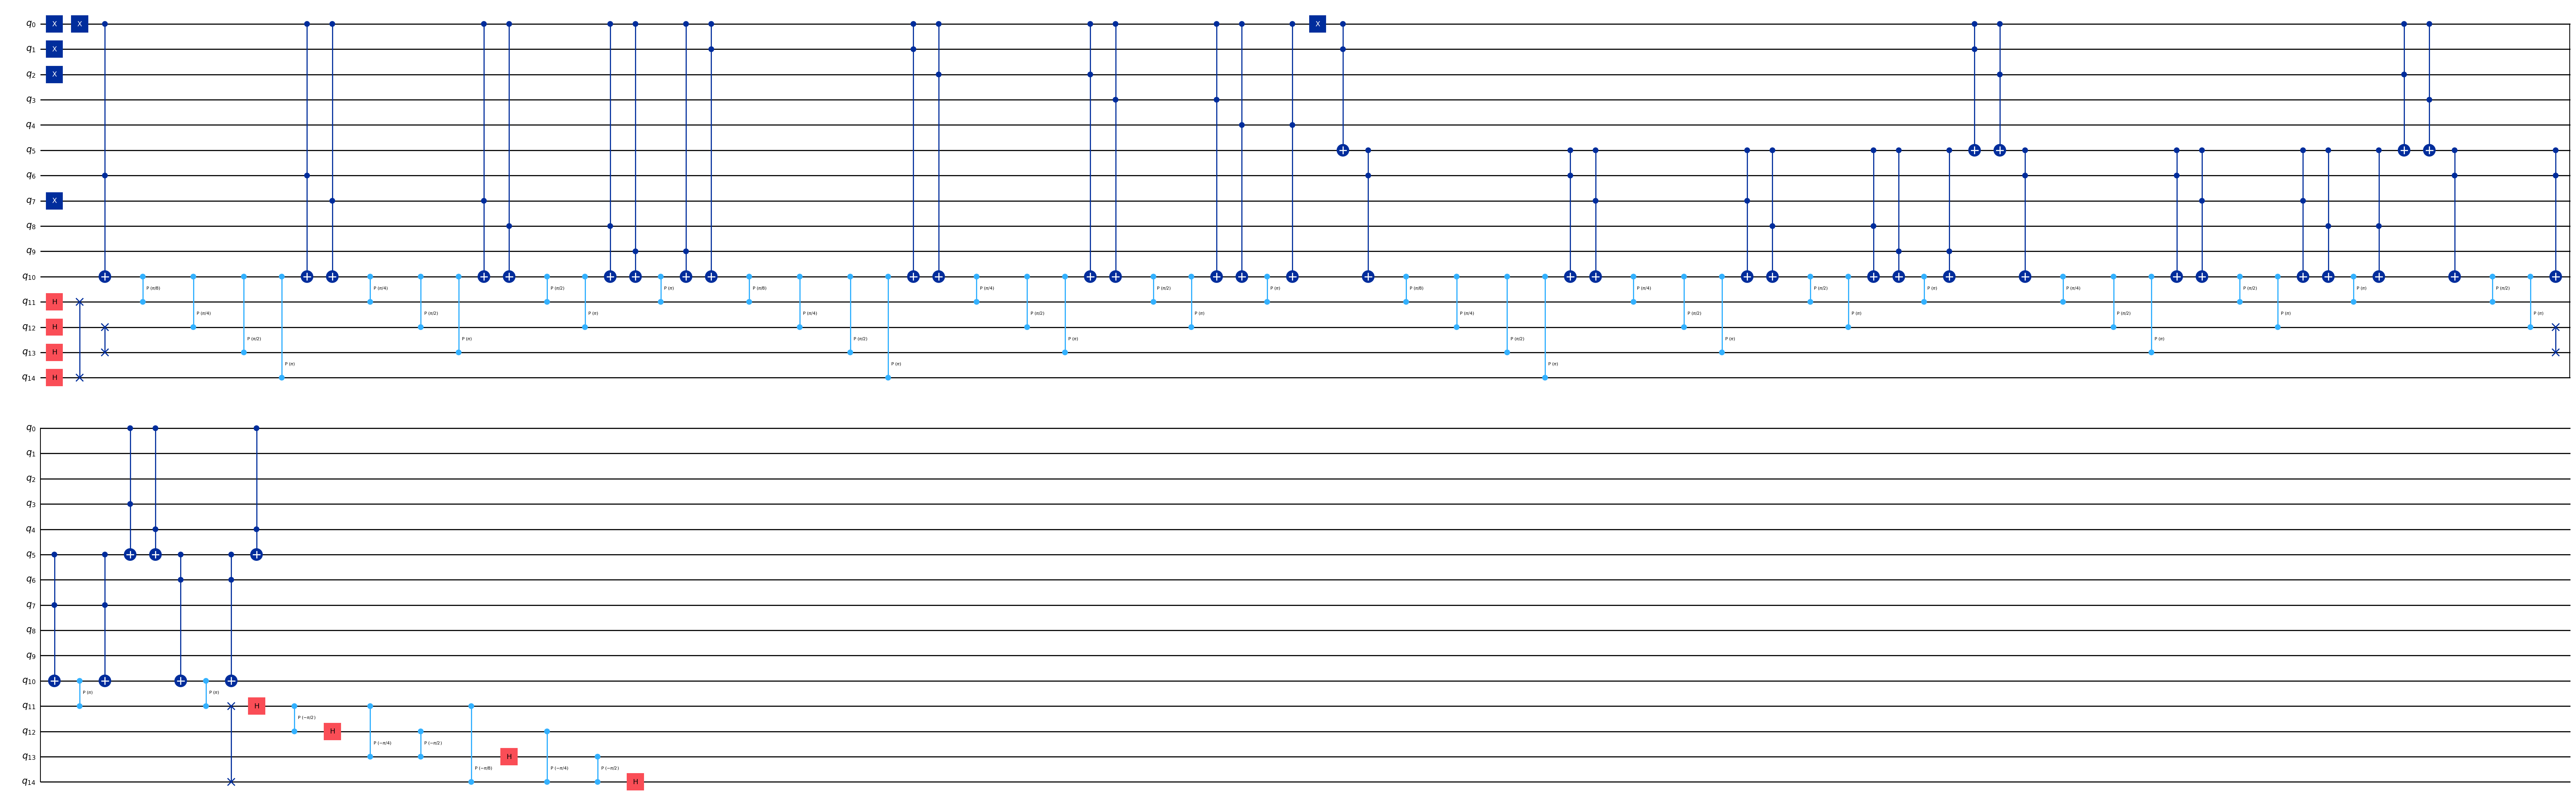

In [7]:
qc_output.draw('mpl', fold = 100)

Verification of the Quantum Calculator circuit

In [8]:
qc_ver = qc_output.copy()
classical_reg = ClassicalRegister(d)
qc_ver.add_register(classical_reg)
qc_ver.measure(list(range(2*d+3, 3*d+2+1)),list(range(d)))

#backend = AerSimulator(method="matrix_product_state")
tqc_m = transpile(qc_ver, simulator_Aer, optimization_level=3)
result_m = simulator_Aer.run(tqc_m, shots=10000).result()
counts_m = result_m.get_counts()

expected_val = (x + y) if z == 0 else (x * y)
expected_bits = "".join([str(i) for i in bits_lsb_first(expected_val, d)[::-1]])

print(f"Expected: {expected_bits}, {counts_m}")

Expected: 0110, {'0110': 10000}
